In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('CC GENERAL.csv')  # adjust filename if Kaggle names it differently
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [2]:
# How many rows (customers) and columns (features)?
print(df.shape)

# Data types and non-null counts for every column
df.info()

# Summary statistics: mean, std, min, max, quartiles
df.describe()

(8950, 18)
<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [3]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [4]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

df.isnull().sum().sum()  # should print 0

np.int64(0)

In [5]:
df = df.drop('CUST_ID', axis=1)

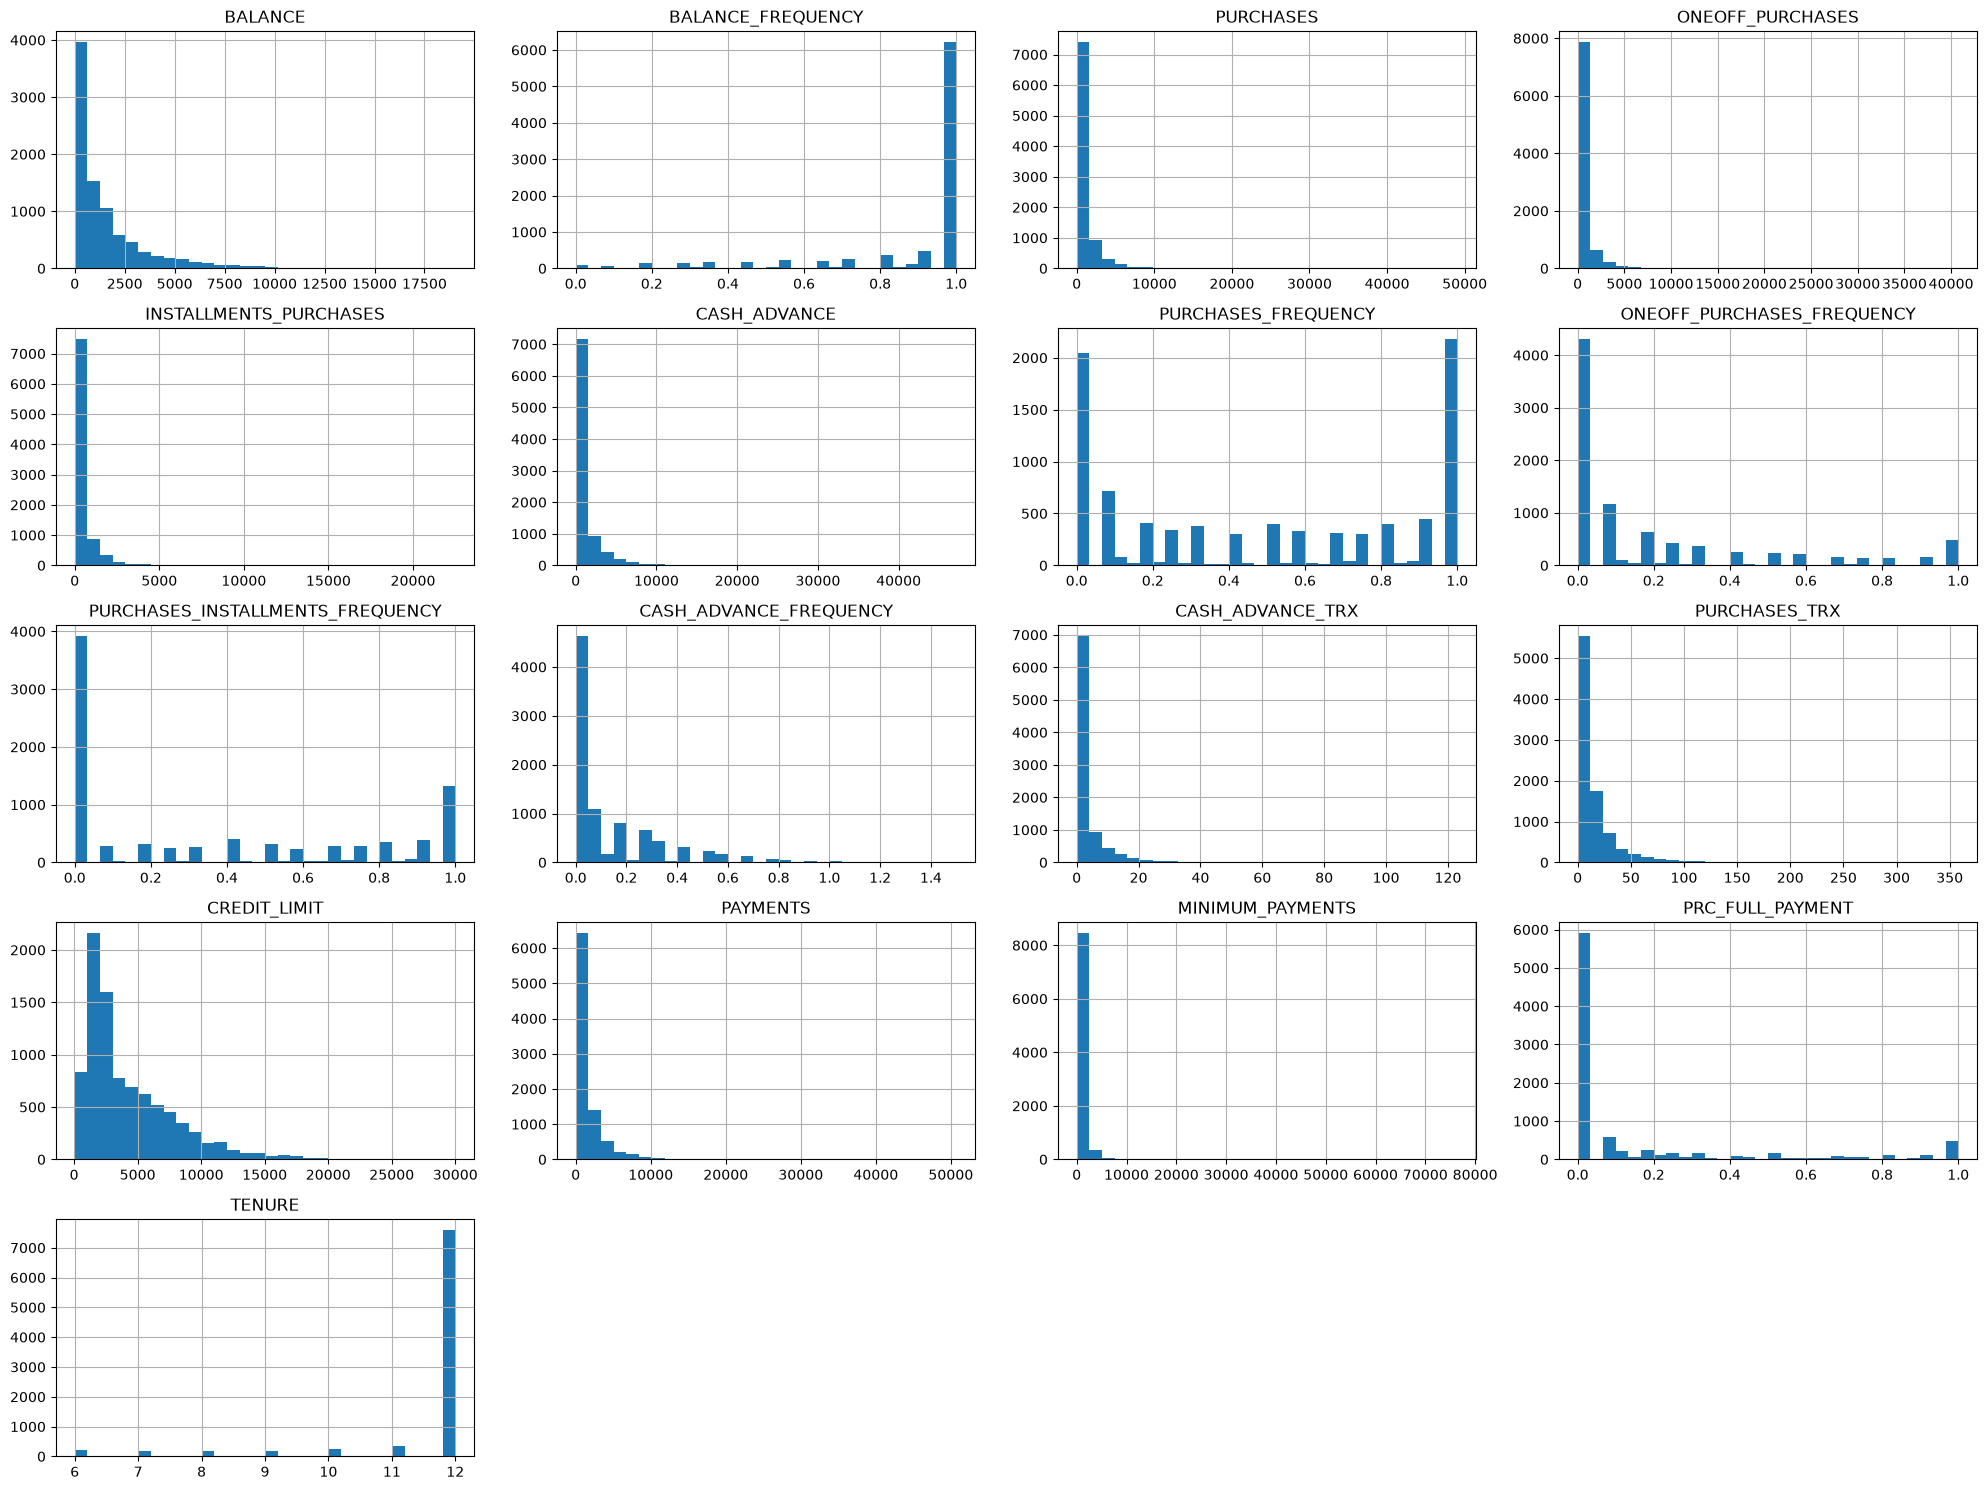

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

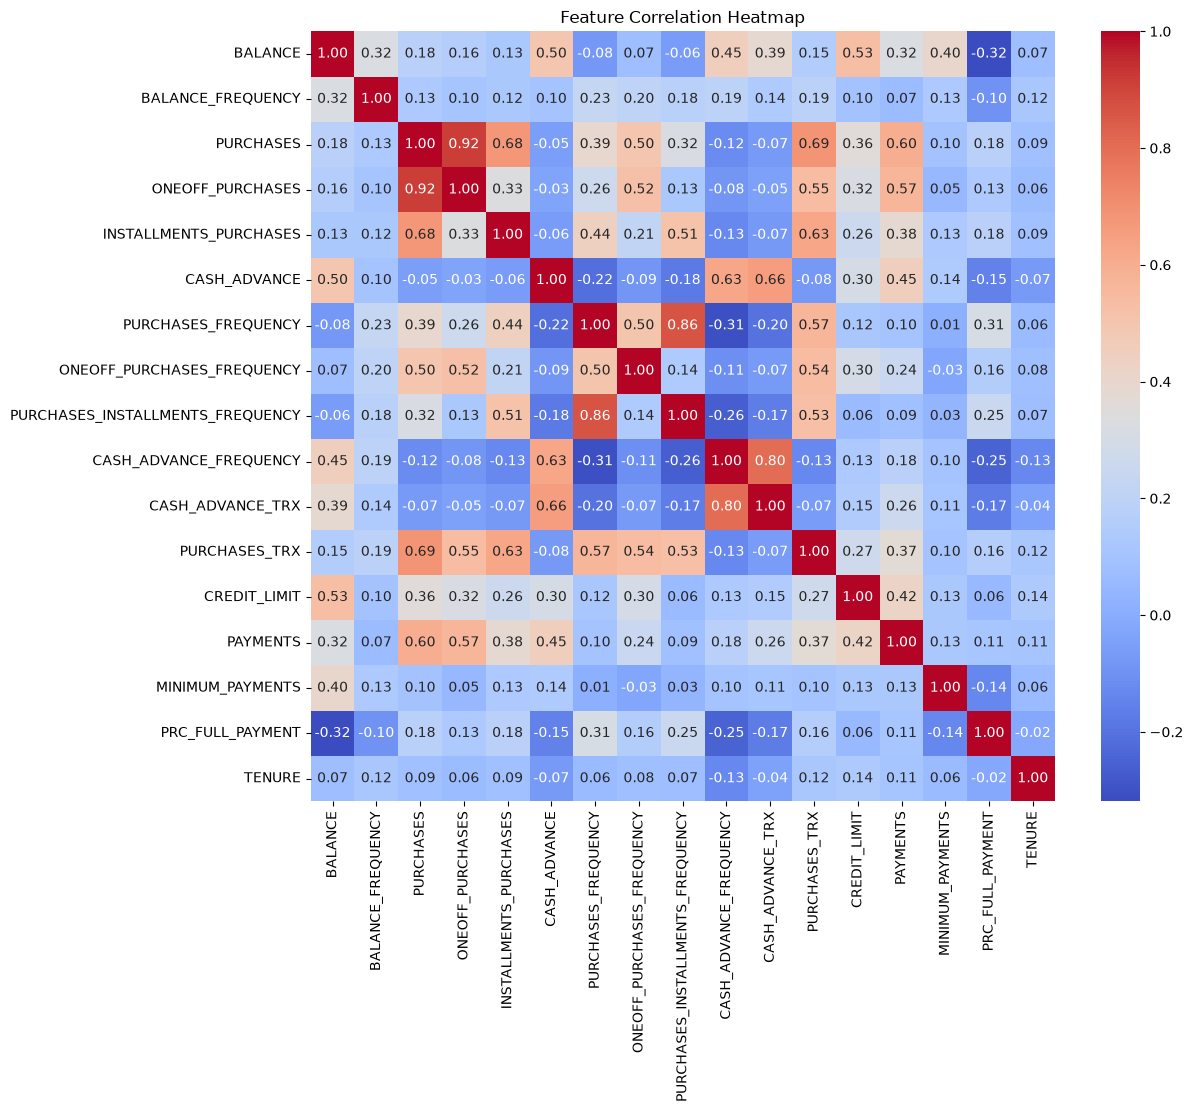

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [9]:
features = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT',
    'TENURE'
]

df_selected = df[features]
df_selected.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763,244.791237,0.000000,12


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)

# scaled_data is a NumPy array — convert back to a DataFrame for readability
df_scaled = pd.DataFrame(scaled_data, columns=features)
df_scaled.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.424900,-0.356934,-0.349079,-0.466786,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,-0.469552,-0.356934,-0.454576,2.605605,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,-0.107668,0.108889,-0.454576,-0.466786,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,0.232058,0.546189,-0.454576,-0.368653,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,-0.462063,-0.347294,-0.454576,-0.466786,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [11]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

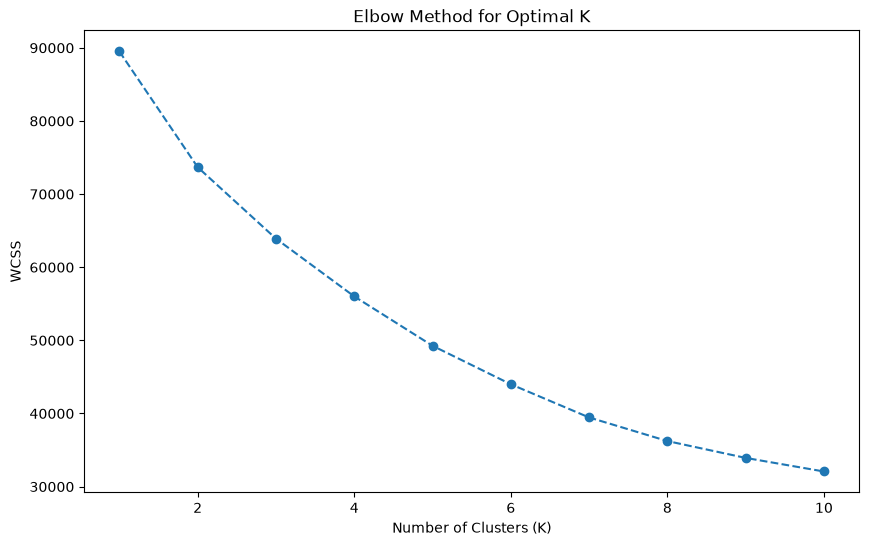

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [13]:
optimal_k = 4  # replace with the K you identified from your elbow plot

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# Attach the cluster label back to the original (unscaled) dataframe for interpretability
df_selected['Cluster'] = cluster_labels
df_selected.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597,1072.340217,0.222222,12,1
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763,244.791237,0.000000,12,0


In [14]:
df_selected['Cluster'].value_counts()

Cluster
0    6083
3    1405
1    1353
2     109
Name: count, dtype: int64

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

df_selected['PCA1'] = pca_data[:, 0]
df_selected['PCA2'] = pca_data[:, 1]

print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

Variance explained: 52.58%


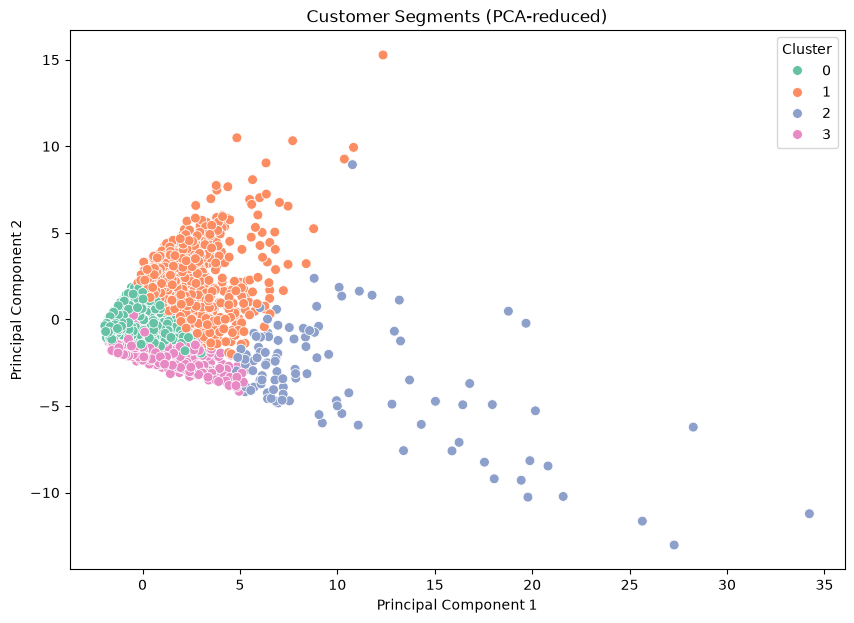

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_selected, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=50)
plt.title('Customer Segments (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [17]:
cluster_profile = df_selected.groupby('Cluster')[features].mean()
cluster_profile

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,
0,1043.332079,571.313030,329.105313,242.516561,561.510919,3236.539653,997.704564,566.373905,0.040234,11.463587
1,5128.466399,1307.464102,820.557428,486.972417,3765.856257,8990.136397,3970.383174,2583.095801,0.025716,11.688840
2,4308.974223,14228.598899,9348.277706,4880.321193,849.703668,11888.073394,13905.711785,3070.341764,0.348337,11.972477
3,175.777538,1554.071096,833.587459,720.995367,112.031543,5036.656853,1818.469462,204.318311,0.753198,11.549466


In [18]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Also save the cluster profile table + names for the API to reference
cluster_names = {
    0: "Standard / Low-Engagement Customers",
    1: "Cash-Advance Reliant Customers",
    2: "Premium High-Value Spenders",
    3: "Financially Disciplined Low-Balance Customers"
}

import json
with open('cluster_names.json', 'w') as f:
    json.dump(cluster_names, f)

cluster_profile.to_csv('cluster_profile.csv')